[<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/> Softmax](https://colab.research.google.com/github/AlbertoLopezCorbalan/eml-albertolopezc/blob/main/k_brazos/softmax.ipynb)  

# Estudio comparativo de algoritmos en un problema de k-armed bandit

El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit.
Se generan gráficas de recompensas promedio para cada algoritmo.

    Author: Alberto López Corbalán
    Email: alberto.lopezc@um.es
    Date: 2026/06/05



## Configuración del entorno

Si el notebook se está ejecutando en Google Colab, clona el repositorio del proyecto. Además, añade la carpeta `src` al `PYTHONPATH` para permitir la importación de módulos propios.

In [1]:
import sys

if "google.colab" in sys.modules:
    print("Google Colab")
    !git clone https://github.com/AlbertoLopezCorbalan/eml-albertolopezc
    %cd eml-albertolopezc/k_brazos

sys.path.append("src")
print(sys.path)

['C:\\Users\\Alberto\\anaconda3\\envs\\EML\\python311.zip', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\DLLs', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\Lib', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML', '', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\Lib\\site-packages', 'src']


## Importación de dependencias
Se importan las librerías y módulos necesarios para la simulación de problemas de bandits multi-brazo.

In [2]:
import numpy as np
from typing import List

from algorithms import Algorithm, Softmax
from arms import ArmNormal, ArmBinomial, ArmBernoulli, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics

## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio.


**Entrada:** Bandido (B), conjunto de algoritmos (A), número de pasos (S), número de ejecuciones (R)

**Salida:** Recompensas medias, porcentaje de selecciones óptimas, regret acumulado y estadísticas por brazo.

- Inicializar las estructuras para almacenar las métricas.
- Para cada ejecución $r \in \{1,\dots,R\}$:
   - Crear una nueva instancia de (B).
   - Reiniciar todos los algoritmos de (A).
   - Para cada paso $s \in \{1,\dots,S\}$
       - Para cada algoritmo $ a \in A$:
            - Seleccionar un brazo $b_s$.
            - Obtener la recompensa $r_s$ al accionar $b_s$.
            - Actualizar las estimaciones de $a$ con $r_s$.
            - Registrar la recompensa obtenida.
            - Actualizar las estadísticas del brazo seleccionado.
            - Calcular las métricas

**Nota:** Cada ejecución consta de $S$ pasos consecutivos de interacción con el bandido $B$. El experimento se repite $R$ veces y las métricas finales se obtienen promediando los resultados de todas las ejecuciones.

In [3]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    regret_accumulated = np.zeros((len(algorithms), steps))  # Matriz para almacenar el rechazo acumulado

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    # Información para la función plot_arm_statistics
    arm_selections = np.zeros((len(algorithms), len(bandit.arms))) # Matriz para almacenar los brazos elegidos
    arm_rewards_sum = np.zeros((len(algorithms), len(bandit.arms))) # Matriz para almacenar las recompensas de cada brazos

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)
        # Obtener la recompensa esperada óptima
        q_max = current_bandit.get_expected_value(current_bandit.optimal_arm)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        regret_accumulated_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.

                arm_selections[idx, chosen_arm] += 1 # Acumular el numero de selecciones de un brazo
                arm_rewards_sum[idx, chosen_arm] += reward # Acumular las recompensas de ese brazo

                regret_accumulated_per_algo[idx] += q_max - current_bandit.get_expected_value(chosen_arm) # Se calcula la perdida
                regret_accumulated[idx, step] += regret_accumulated_per_algo[idx]  # Acumulamos la perdida por no elegir el brazo correcto
                
                if optimal_arm == chosen_arm:
                    optimal_selections[idx, step] += 1 # Si el brazo elegido se corresponda con el brazo óptimo

    
    rewards /= runs
    regret_accumulated /= runs
    optimal_selections = (optimal_selections / runs) * 100 # Calcula el porcentaje de selecciones óptimas

    # Calculamos el promedio de las ganancias de cada brazo
    avg_arm_rewards = np.divide(arm_rewards_sum, arm_selections, out=np.zeros_like(arm_rewards_sum), where=arm_selections > 0)

    return rewards, optimal_selections, regret_accumulated, avg_arm_rewards, arm_selections

## Configuración del experimento
La selección del brazo para este notebook se fundamenta en el método de ascenso del gradiente softmax. Cada brazo tiene la siguiente probabilidad de ser elegido:

$$
P(A_t = a)
=
\frac{e^{Q_t(a)/\tau}}
{\sum_{b=1}^{k} e^{Q_t(b)/\tau}}
=
\pi_t(a)
$$

donde:

- $Q_t(a)$ recompensa esperada al ejecutar la acción a en el instante $t$.
- $k$ es el número total de acciones disponibles.
- $\tau$ es el parámetro de temperatura que controla el equilibrio entre exploración y explotación.
- $\pi_t(a)$ representa la política de selección de acciones en el instante $t$.

Un parámetro de temperatura ($\tau$) muy elevado resultará en las probabilidades distribuidas igualitariamente entre todas las acciones (exploración), mientras que un valor muy bajo asignará el grueso de la probabilidad al elemento con mayor recompensa (explotación).

Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 3 algoritmos softmax para valores de temperatura: [0.5, 1, 2]





In [4]:
# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Definir los algoritmos a comparar. En este caso son 3 algoritmos softmax con diferentes temperaturas (tau).
algorithms = [Softmax(k=k, tau=0.5), Softmax(k=k, tau=1.0), Softmax(k=k, tau=2.0)]

## Ejecución del experimento Normal
Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución gaussina con desviación 1.

Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


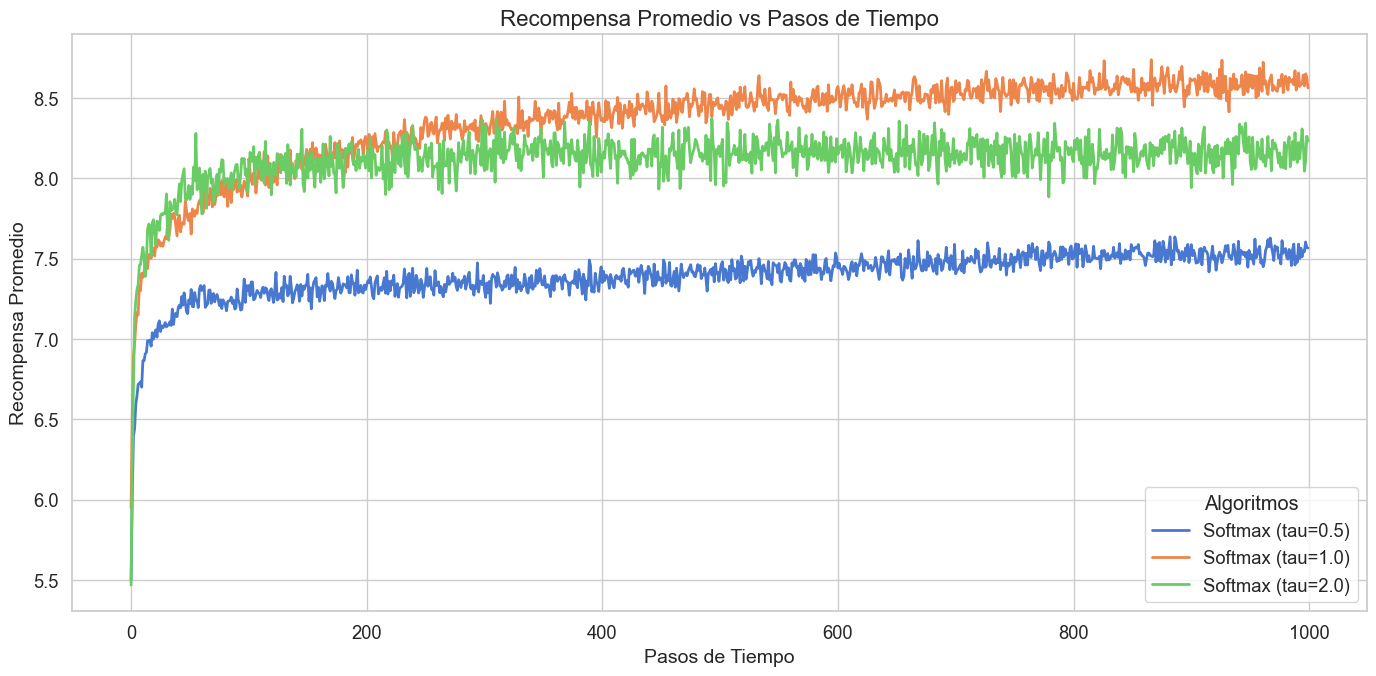

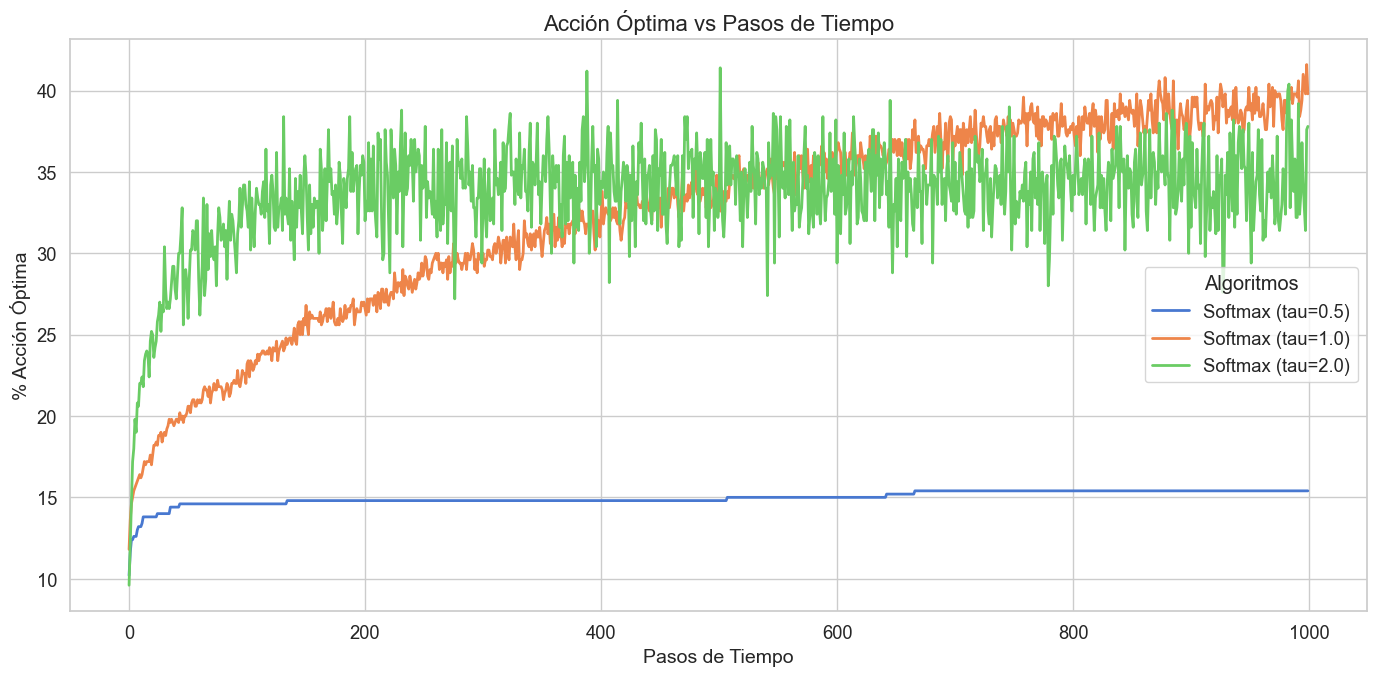

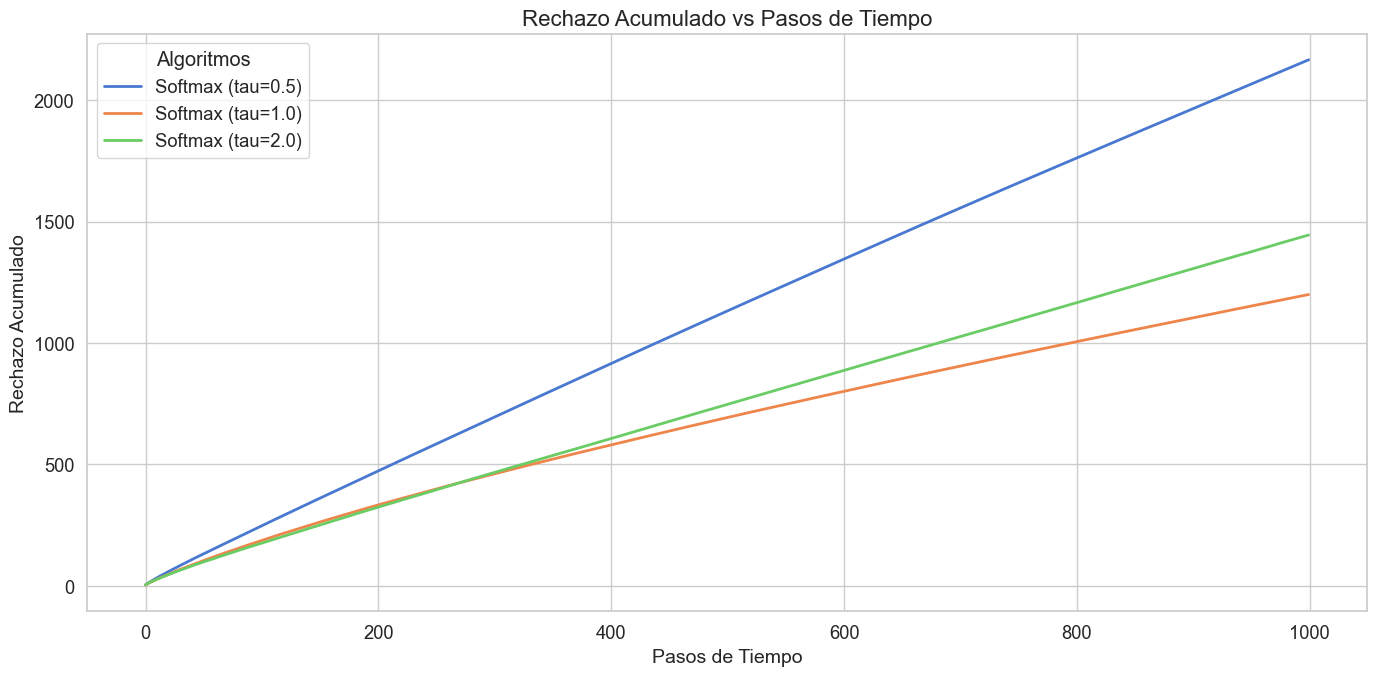

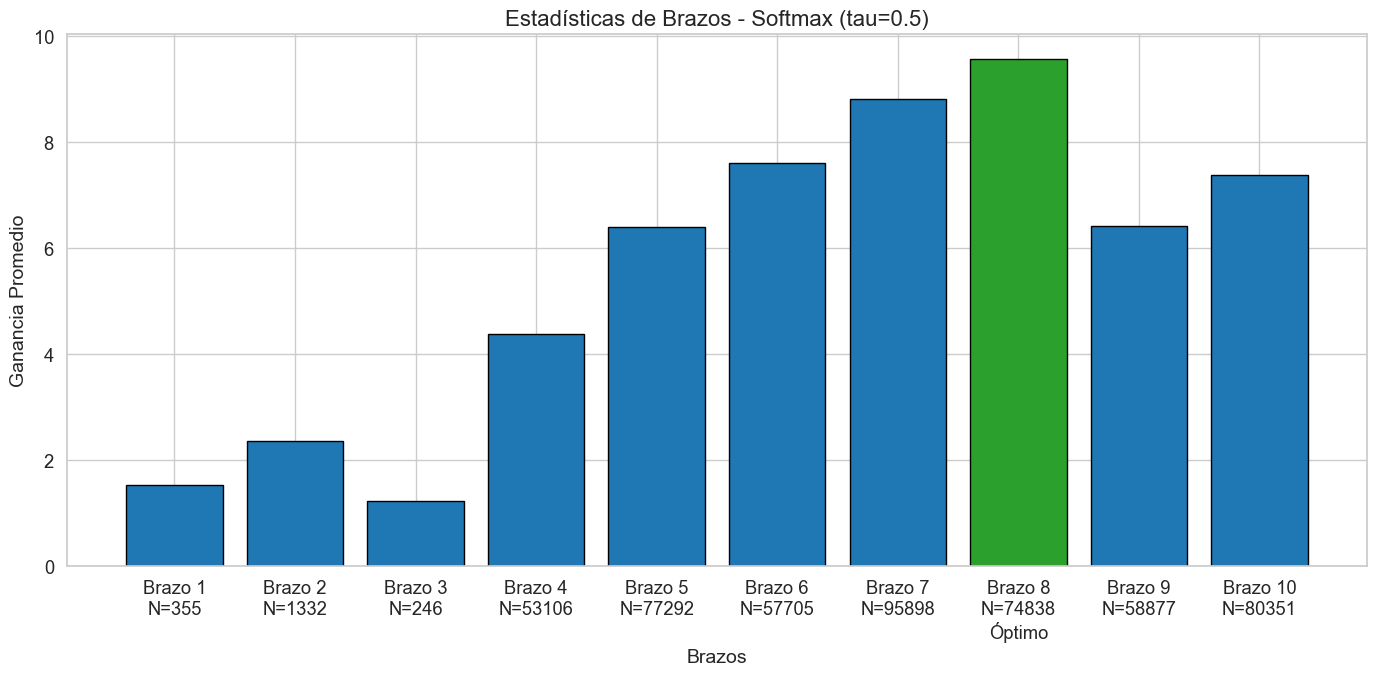

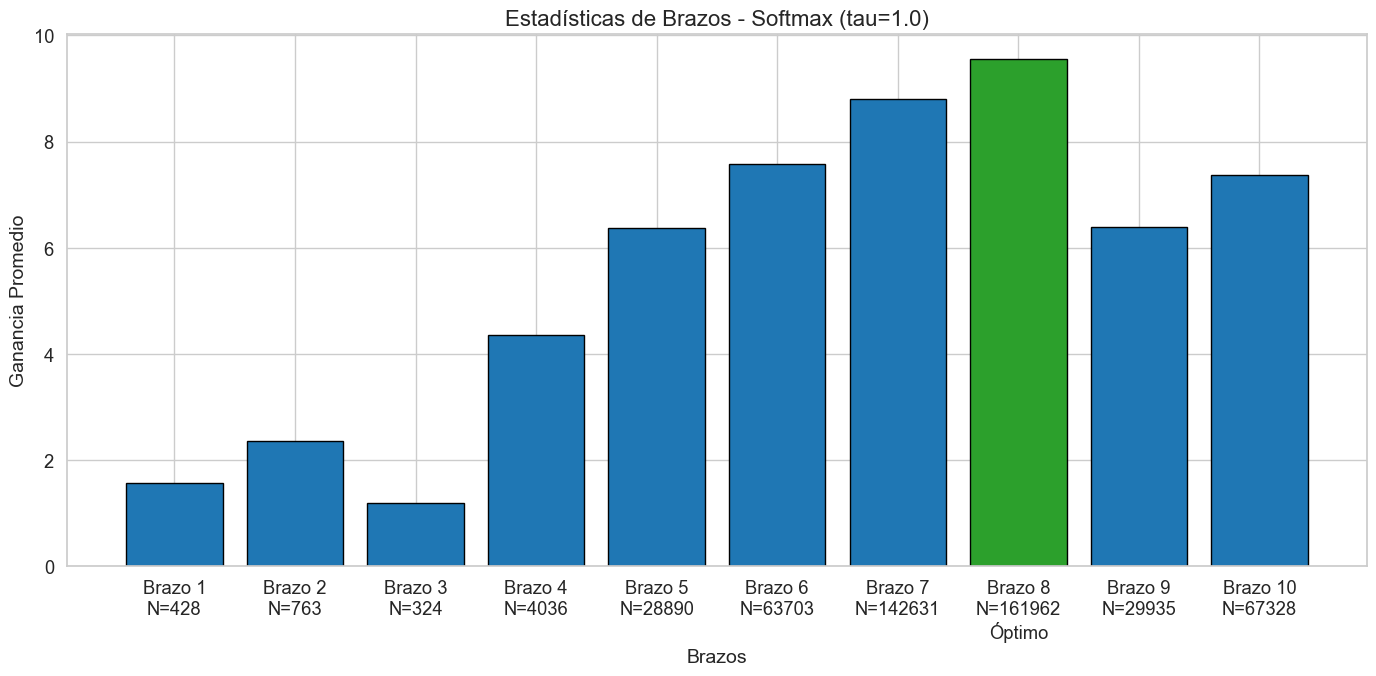

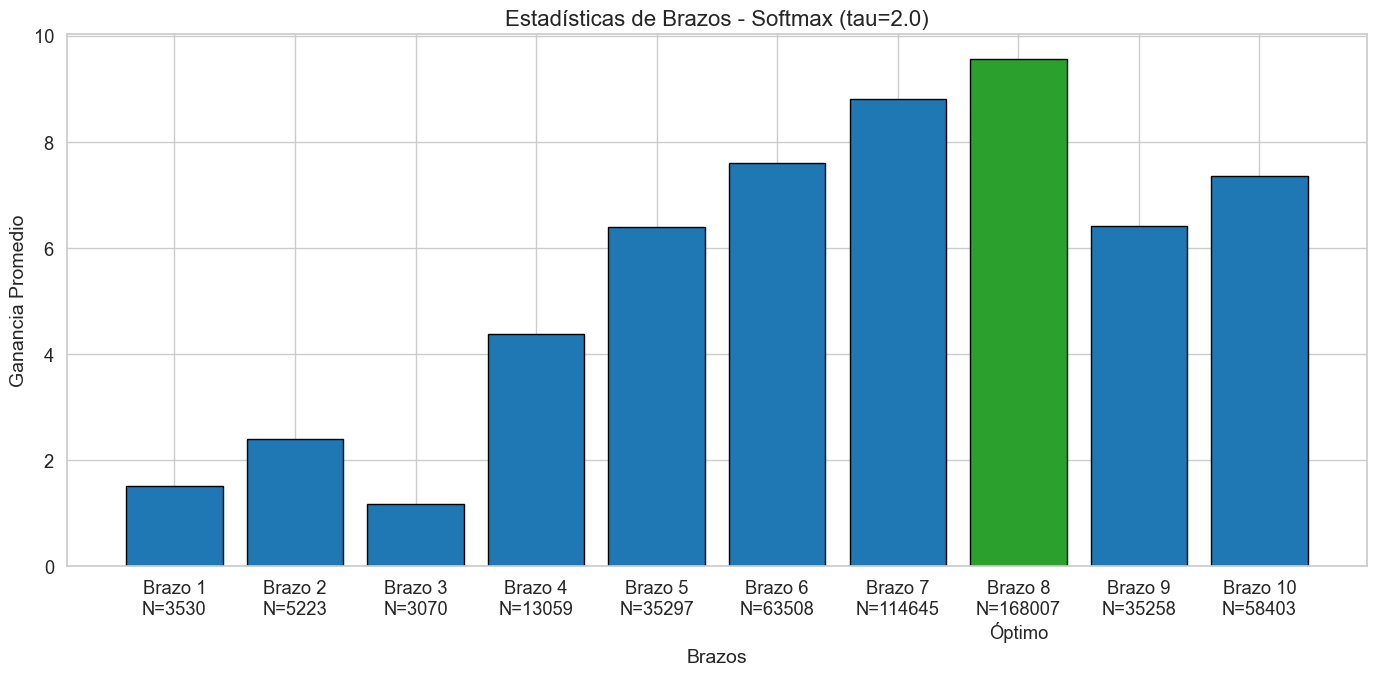

In [5]:
# Creación del bandit
bandit_normal = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit_normal)

optimal_arm = bandit_normal.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit_normal.get_expected_value(optimal_arm)}")

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret_accumulated, avg_arm_rewards, arm_selections = run_experiment(bandit_normal, algorithms, steps, runs)

# Mostramos los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_regret(steps, regret_accumulated, algorithms)
plot_arm_statistics(avg_arm_rewards, arm_selections, optimal_arm, algorithms)

Se muestran unos gráficos de líneas donde se analiza el desempeño de diferentes estrategias del algoritmo **softmax** en un entorno de multi-armed bandit. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra la **recompensa promedio/acción óptima/rechazo acumulado** por cada algoritmo. 

Además de las gráficas de líneas, se muestra un **histograma de barras** que resume el comportamiento de cada algoritmo respecto a los distintos brazos del bandido. En el eje **x** aparecen los brazos disponibles, mientras que en el eje **y** se representa la **recompensa media observada** para cada uno de ellos. Debajo de cada barra se indica el valor **N**, que corresponde al número de veces que dicho brazo ha sido seleccionado durante todas las ejecuciones del experimento, **N** suma en total ``stepsxruns``. 

Se han realizado pruebas con $\tau$ inferiores y superiores a los elegidos, pero presentaban resultados peores, por lo que se han omitido de las métricas.

En el caso del algoritmo **softmax**, se observa cómo la temperatura $\tau$ controla directamente el grado de exploración del agente. Para valores bajos como **$\tau = 0.5$**, el algoritmo se comporta de forma más determinista, favoreciendo con mayor frecuencia los brazos que presentan una recompensa media más alta. Esto permite una convergencia rápida hacia buenas soluciones, aunque con menor exploración del resto de opciones.

Con una temperatura intermedia como **$\tau = 1$**, se obtiene un equilibrio más estable entre exploración y explotación. Sin embargo, en este caso se observa que le cuesta más tiempo incorporar la acción óptima dentro de su política en comparación con $\tau = 2$, ya que la exploración es más moderada y menos uniforme al inicio.


Por otro lado, para **$\tau = 2$**, la política se vuelve más exploratoria, ya que las probabilidades de selección entre brazos se distribuyen de forma más uniforme. A pesar de esta diferencia inicial en la dinámica de aprendizaje, $\tau = 1 $ y $\tau=2$ terminan convergiendo a resultados muy similares a largo plazo.

No obstante, comparado con otros métodos analizados, el rendimiento global de softmax resulta relativamente bajo. Aunque es capaz de converger hacia políticas razonables, lo hace de forma más lenta y obtiene recompensas acumuladas inferiores.

---

## Ejecución del experimento Binomial
En este bloque se genera un problema de bandido multibrazo con $K$ brazos cuyas recompensas siguen distribuciones binomiales.

Bandit with 10 arms: ArmBinomial(n=10, p=0.4), ArmBinomial(n=10, p=0.86), ArmBinomial(n=10, p=0.22), ArmBinomial(n=10, p=0.69), ArmBinomial(n=10, p=0.58), ArmBinomial(n=10, p=0.15), ArmBinomial(n=10, p=0.79), ArmBinomial(n=10, p=0.67), ArmBinomial(n=10, p=0.12), ArmBinomial(n=10, p=0.88)
Optimal arm: 10 with expected reward=8.8


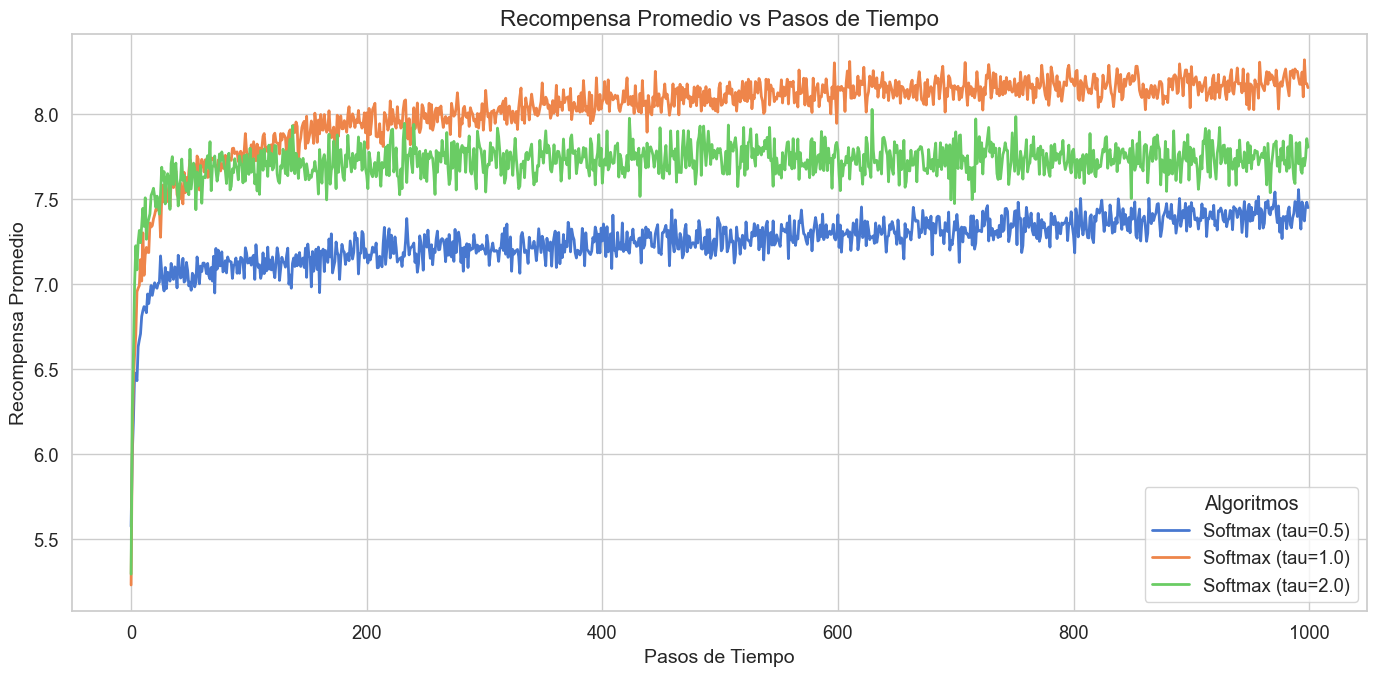

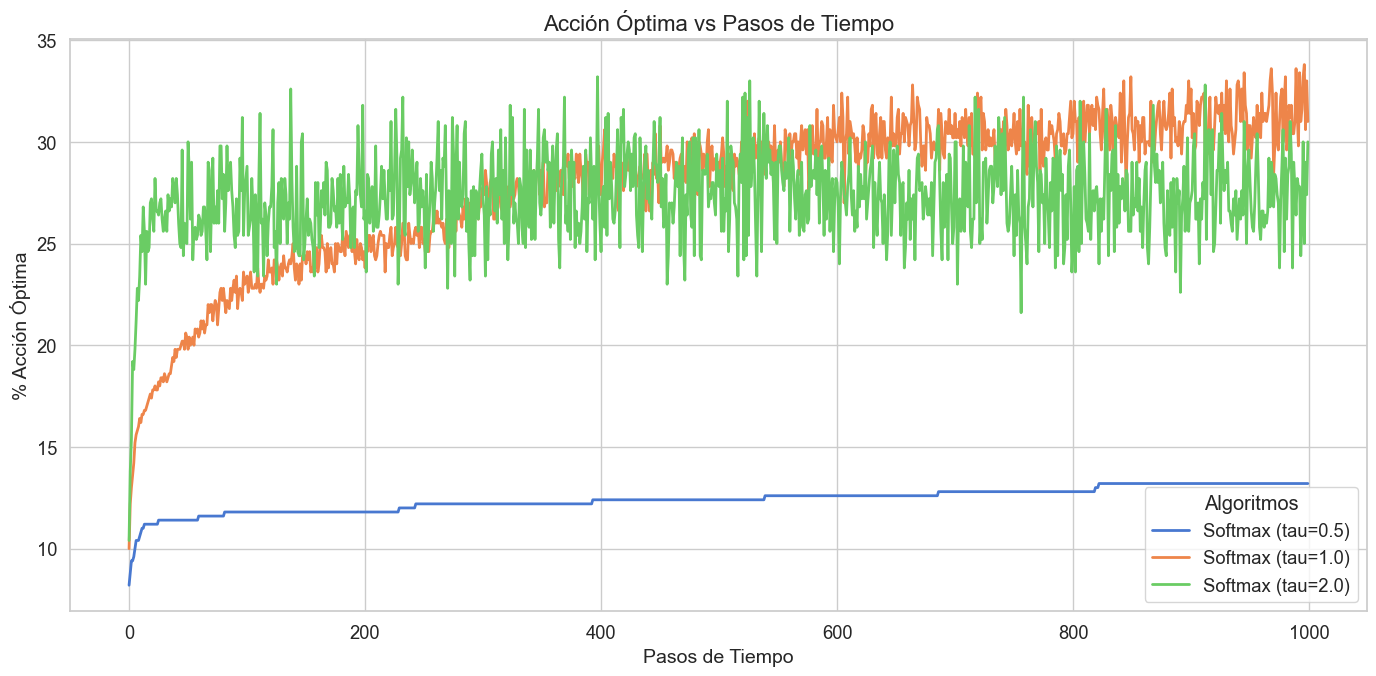

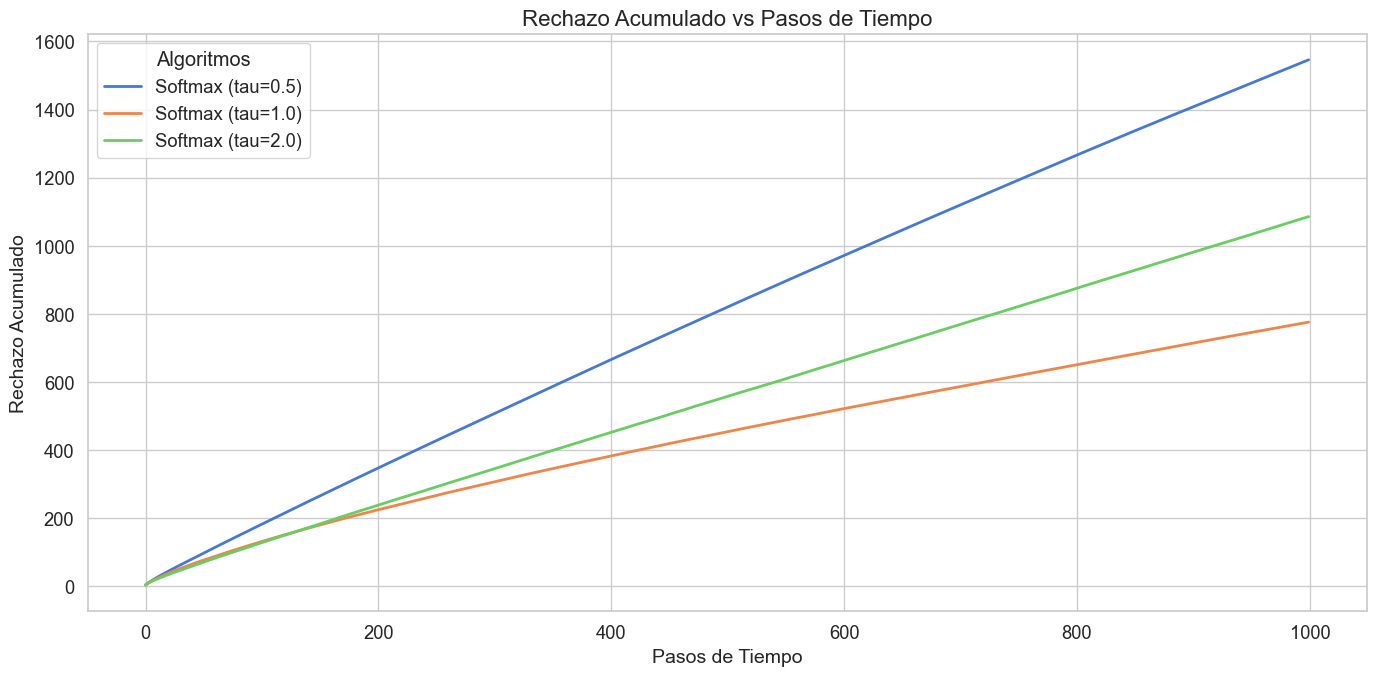

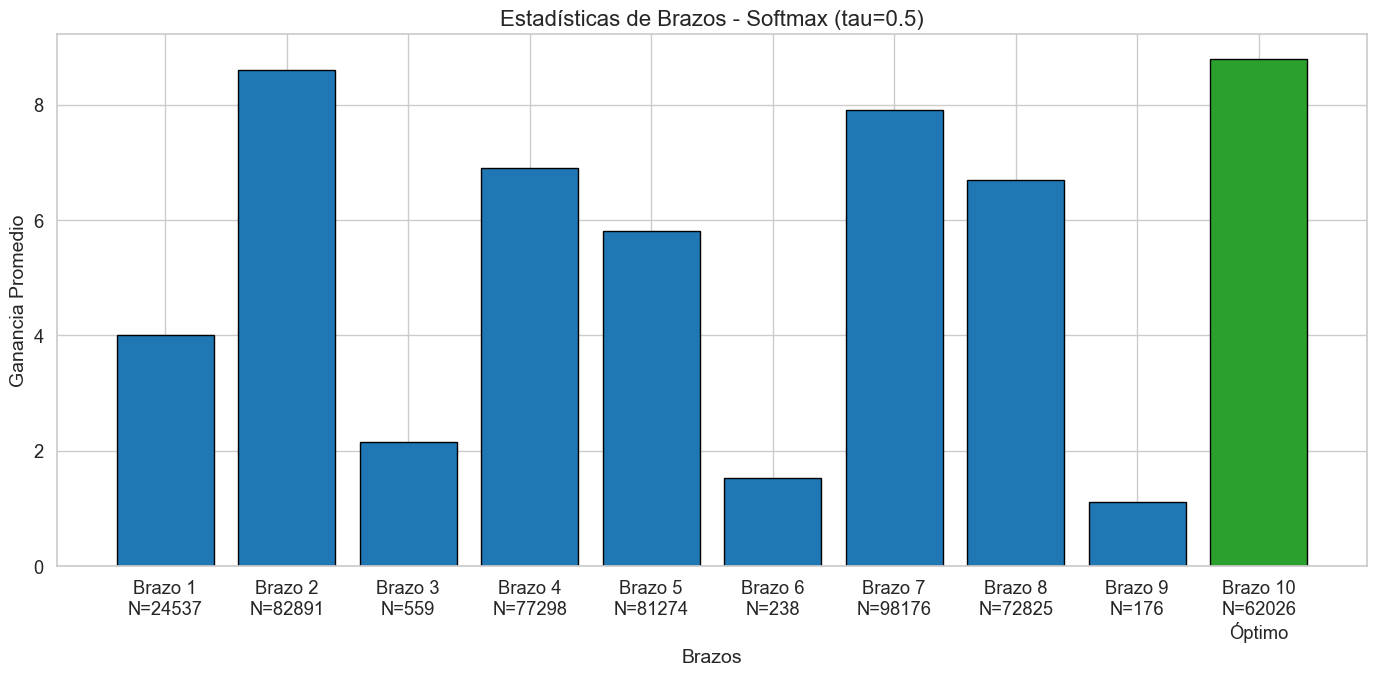

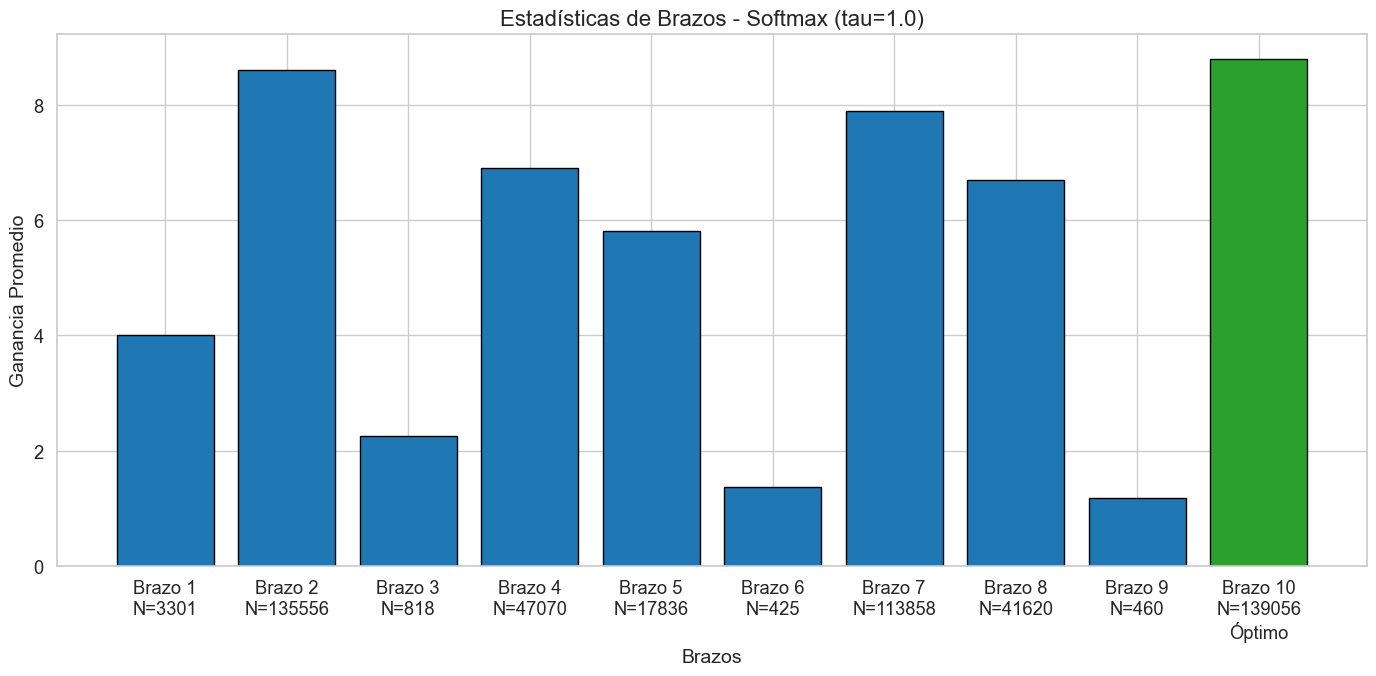

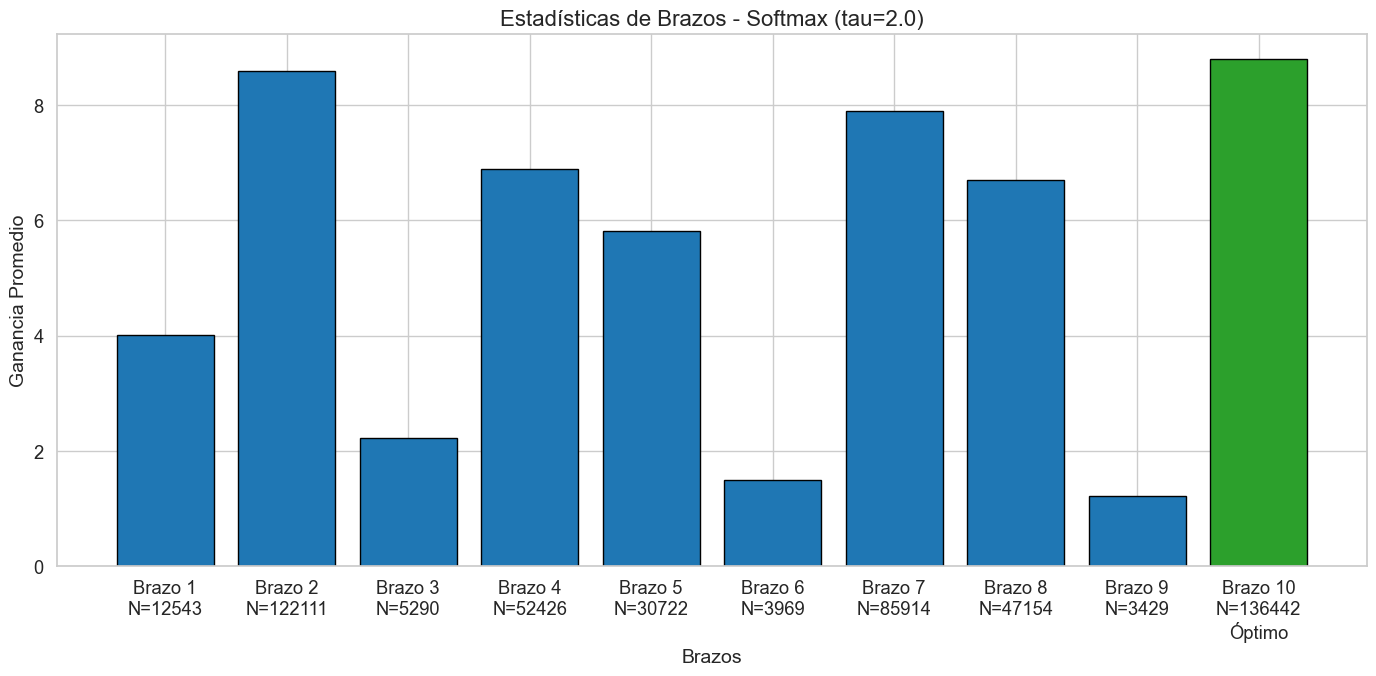

In [6]:
# Se fija la semilla de nuevo inicio de cada experimento para garantizar la reproducibilidad de cada ejecución completa
# El objetivo es poder comparar distintas técnica (UCB1, softmax...) ya que cada técnica genera un número de veces diferente números aleatorios
np.random.seed(42)

# Creación del bandit
bandit_binomial = Bandit(arms=ArmBinomial.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit_binomial)

optimal_arm = bandit_binomial.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit_binomial.get_expected_value(optimal_arm)}")

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret_accumulated, avg_arm_rewards, arm_selections = run_experiment(bandit_binomial, algorithms, steps, runs)

# Mostramos los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_regret(steps, regret_accumulated, algorithms)
plot_arm_statistics(avg_arm_rewards, arm_selections, optimal_arm, algorithms)

Tras repetir la misma ejecución en un experimento con una distribución de Bernoulli, se observa que el rendimiento global de las distintas estrategias es bastante similar entre sí. Sin embargo, el porcentaje de selección de la acción óptima disminuye ligeramente. Este comportamiento es coherente con la configuración del problema, ya que existen varios brazos con probabilidades de recompensa muy cercanas al óptimo. Esto hace que sea más difícil distinguir de forma consistente el mejor brazo.

Como consecuencia, aunque el algoritmo logra un rendimiento global similar, la frecuencia con la que se selecciona exactamente la acción óptima es menor.

## Ejecución del experimento Bernoulli
En este bloque se genera un problema de bandido multibrazo con $K$ brazos cuyas recompensas siguen distribuciones de Bernoulli.

Bandit with 10 arms: ArmBinomial(n=1, p=0.4), ArmBinomial(n=1, p=0.86), ArmBinomial(n=1, p=0.22), ArmBinomial(n=1, p=0.69), ArmBinomial(n=1, p=0.58), ArmBinomial(n=1, p=0.15), ArmBinomial(n=1, p=0.79), ArmBinomial(n=1, p=0.67), ArmBinomial(n=1, p=0.12), ArmBinomial(n=1, p=0.88)
Optimal arm: 10 with expected reward=0.88


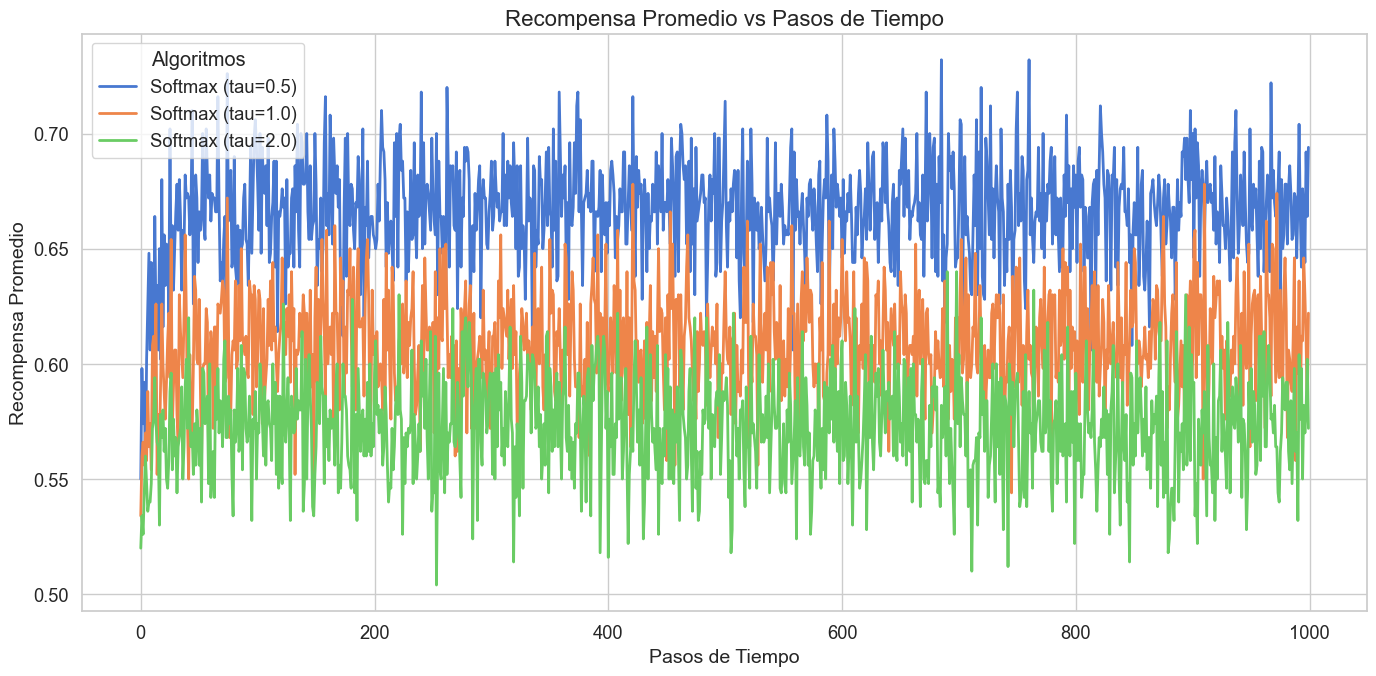

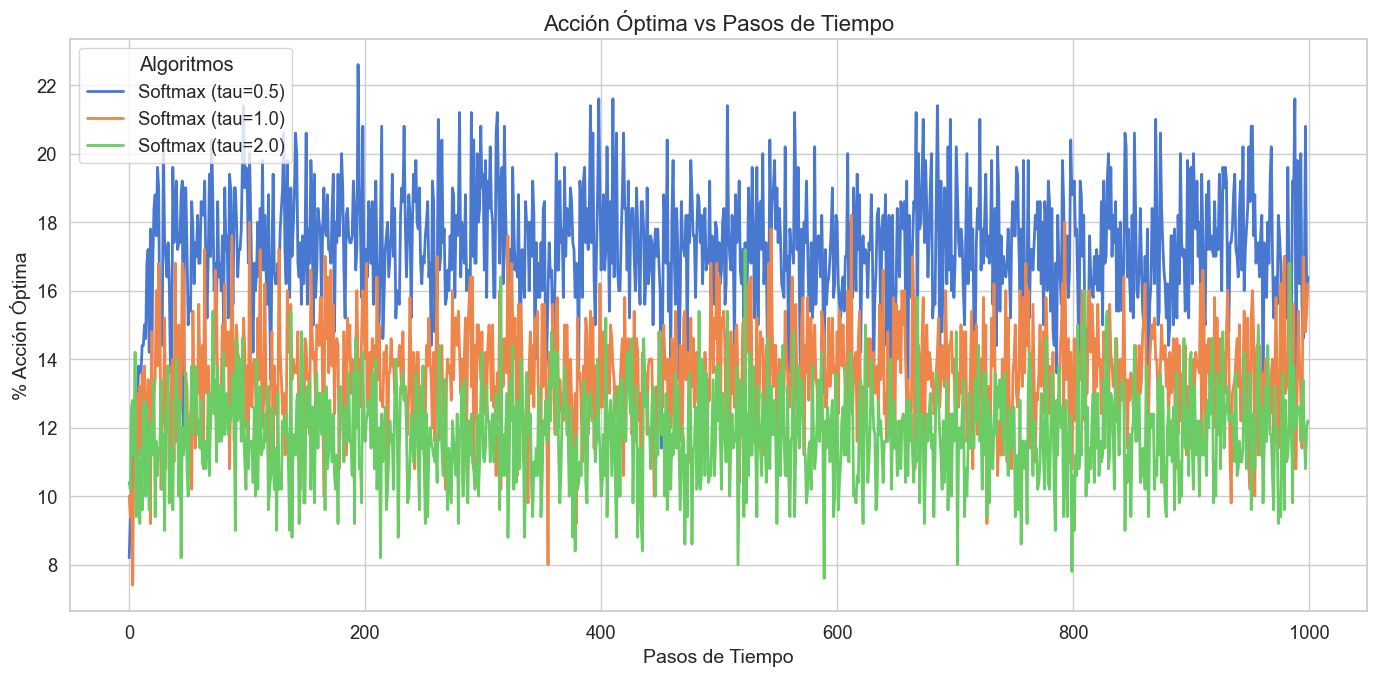

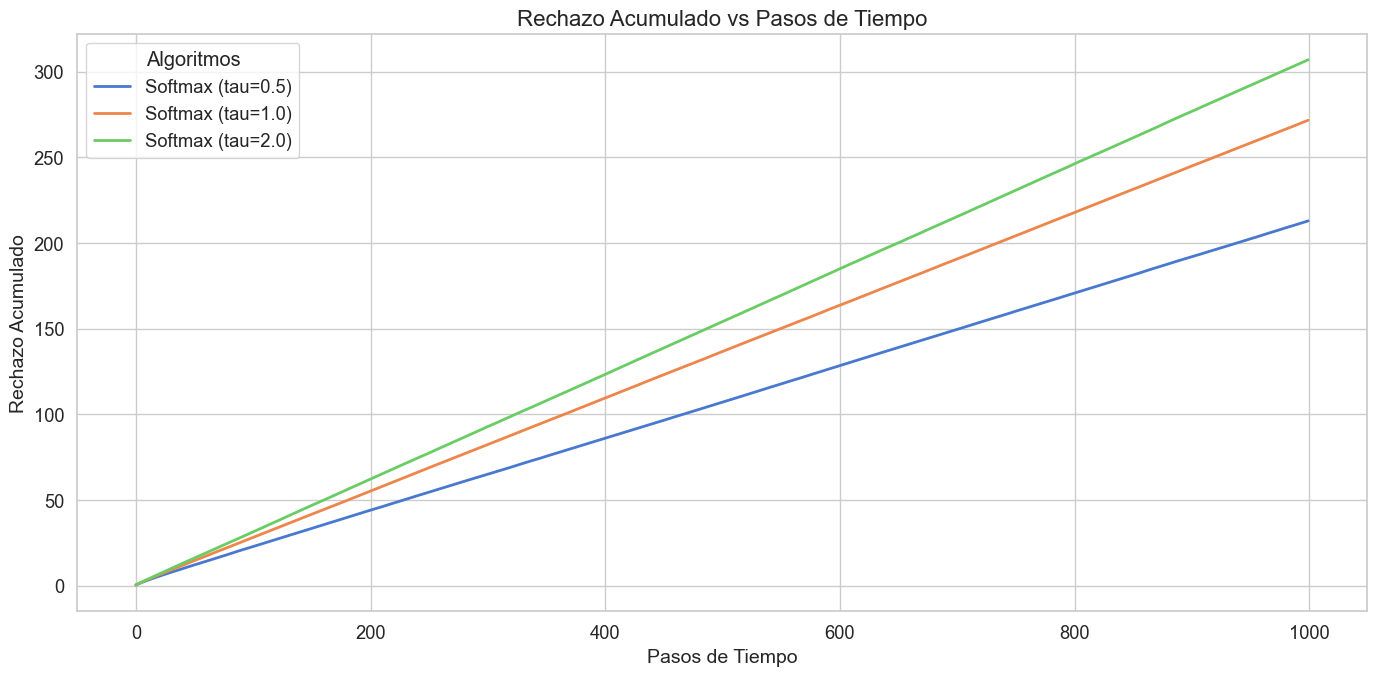

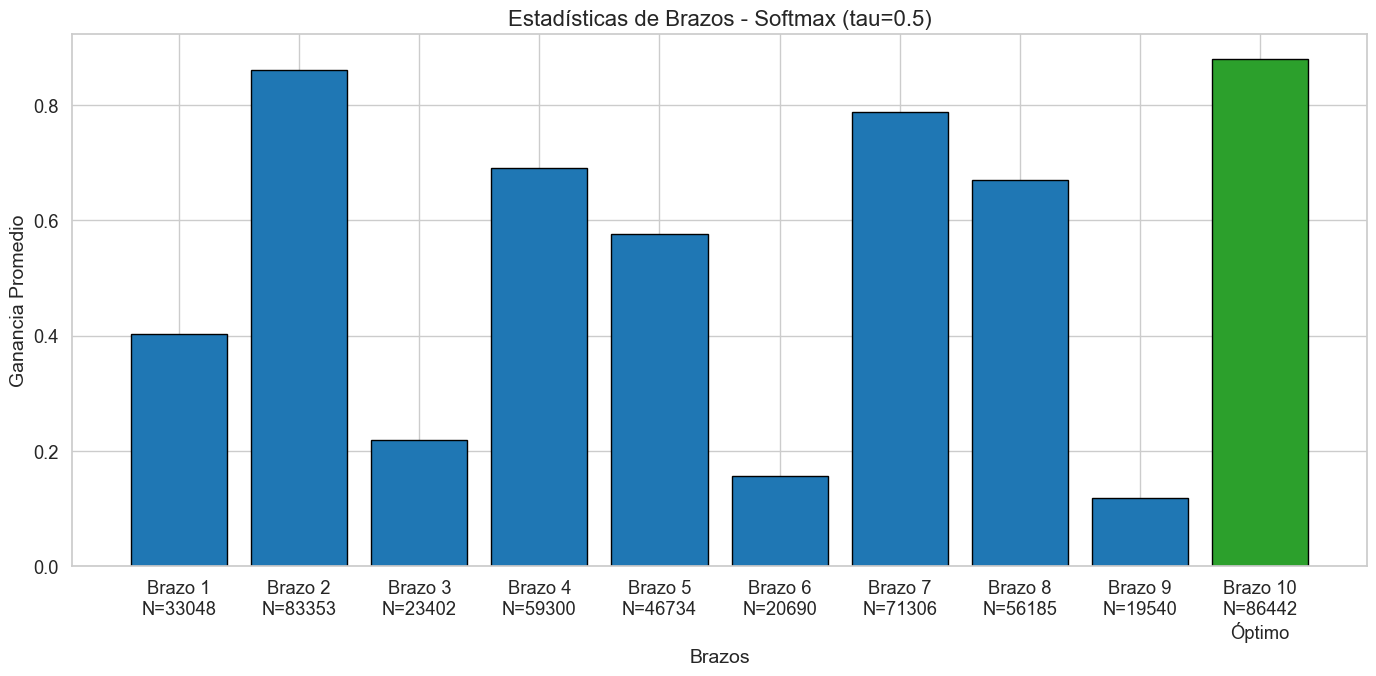

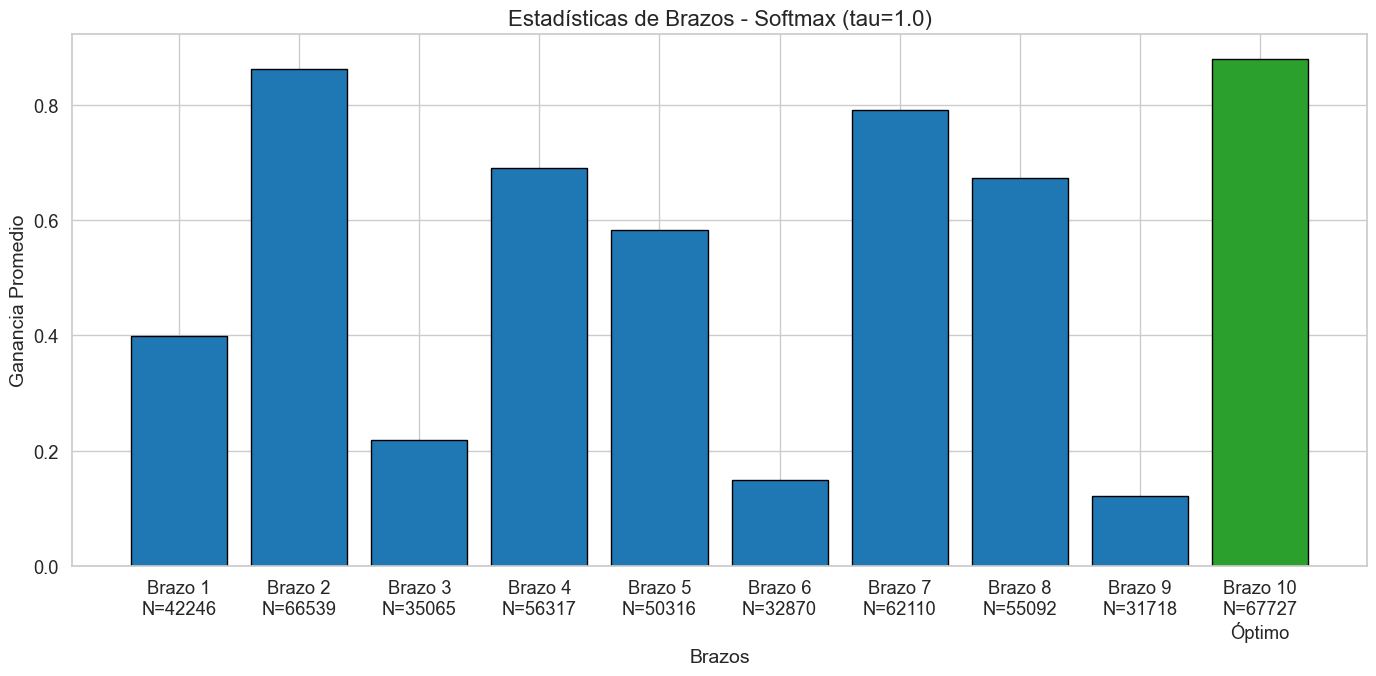

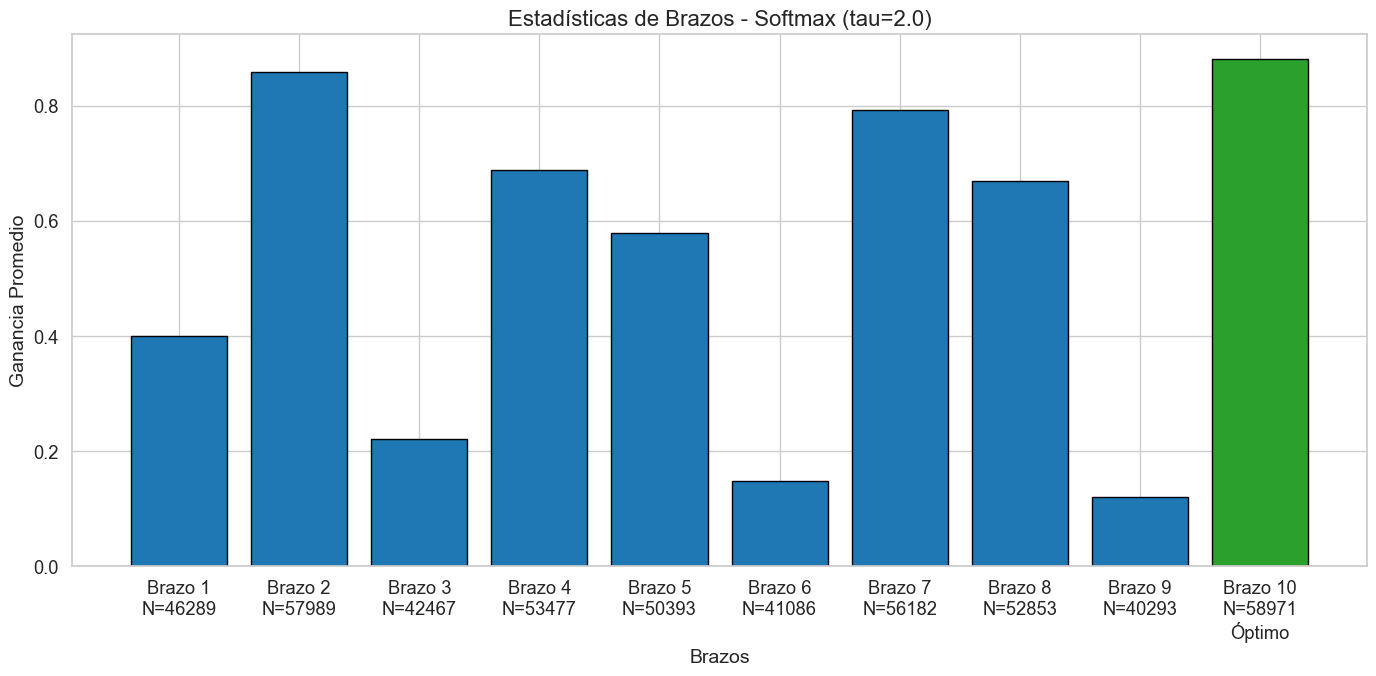

In [7]:
# Se fija la semilla de nuevo inicio de cada experimento para garantizar la reproducibilidad de cada ejecución completa
# El objetivo es poder comparar distintas técnica (UCB1, softmax...) ya que cada técnica genera un número de veces diferente números aleatorios
np.random.seed(42)

# Creación del bandit
bandit_bernoulli = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit_bernoulli)

optimal_arm = bandit_bernoulli.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit_bernoulli.get_expected_value(optimal_arm)}")

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret_accumulated, avg_arm_rewards, arm_selections = run_experiment(bandit_bernoulli, algorithms, steps, runs)

# Mostramos los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_regret(steps, regret_accumulated, algorithms)
plot_arm_statistics(avg_arm_rewards, arm_selections, optimal_arm, algorithms)

Tras repetir la misma ejecución en un experimento con distribución Bernoulli, se observan diferencias más claras en comparación con los casos anteriores. En este entorno, la configuración con **$\tau = 0.5$** obtiene el mejor rendimiento, seguida de **$\tau = 1$**, mientras que valores más altos como **$\tau = 2$** muestran un comportamiento ligeramente peor.

Este resultado puede explicarse por la naturaleza de la distribución Bernoulli y la estructura del problema, donde varios brazos presentan probabilidades de recompensa relativamente cercanas. En este contexto, una menor temperatura favorece una selección más rápida y consistente de los brazos con mayor probabilidad de éxito, evitando una exploración excesiva que no aporte información significativamente nueva.

---

## Conclusiones

Hemos estudiado un **experimento de toma de decisiones secuenciales**, modelado con un **Multi-Armed Bandit (MAB)**. Este problema es fundamental en el aprendizaje por refuerzo y la teoría de decisiones. La idea principal es que un agente debe aprender cuál es la mejor acción (brazo del bandit) a partir de la experiencia acumulada. Para este estudio nos hemos centrado en el algoritmo softmax, llegando a las siguientes conclusiones:

- La temperatura $\tau$ controla el equilibrio entre exploración y explotación: valores bajos inducen un comportamiento más determinista, mientras que valores altos incrementan la exploración.

- En este entorno, **$\tau = 1$ obtiene el mejor rendimiento global**, seguido de **$\tau = 2$**, lo que indica que un nivel intermedio de exploración resulta más adecuado para identificar de forma eficiente los brazos óptimos.

- El caso de **$\tau = 0.5$** tiende a ser más explotador desde etapas tempranas, lo que puede acelerar la convergencia inicial pero reduce la capacidad de explorar suficientemente el espacio de acciones, penalizando ligeramente el rendimiento final.

- En general, el algoritmo softmax muestra un comportamiento estable frente a distintos tipos de distribución de recompensas (normal, binomial y Bernoulli), aunque en el caso Bernoulli se aprecia una mayor sensibilidad a la temperatura.

- A pesar de ello, el rendimiento global de softmax es relativamente bajo en comparación con otros algoritmos estudiados.

En conclusión, **los resultados muestran que un nivel intermedio de exploración (τ = 1) proporciona el mejor equilibrio entre exploración y explotación, mejorando el rendimiento global**.